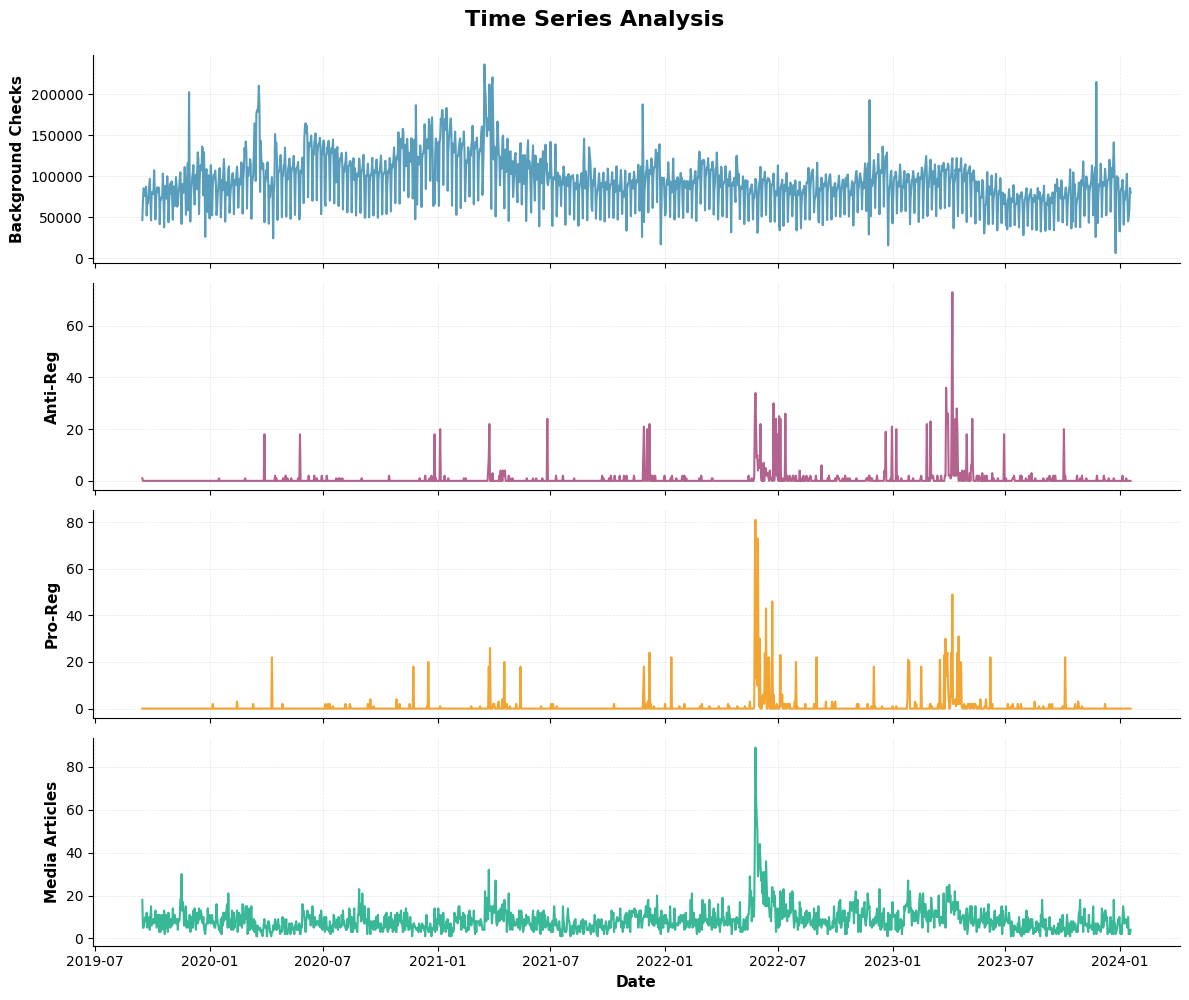

In [35]:
import pandas as pd
import matplotlib.pyplot as plt
from causationentropy.core import discover_network

# Load data
df = pd.read_csv("data/all_dailies_reg.csv")
proquest_df = pd.read_csv("data/proquest.csv")

# Count articles per day
proquest_df['PubDate'] = pd.to_datetime(proquest_df['PubDate'])
articles_per_day = proquest_df.groupby('PubDate').size().reset_index(name='Media Articles')

# Prepare main dataframe
df['timestamp'] = pd.to_datetime(df['timestamp'])

# Merge datasets
merged = pd.merge(
    df, 
    articles_per_day, 
    left_on='timestamp', 
    right_on='PubDate', 
    how='inner'
).drop(columns=['PubDate'])

# Rename columns for clarity
merged = merged.rename(columns={
    'bg_checks': 'Background Checks',
    'anti_reg': 'Anti-Reg',
    'pro_reg': 'Pro-Reg'
})

fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)
fig.suptitle('Time Series Analysis', fontsize=16, fontweight='bold', y=0.995)

# Define colors
colors = ['#2E86AB', '#A23B72', '#F18F01', '#06A77D']
variables = ['Background Checks', 'Anti-Reg', 'Pro-Reg', 'Media Articles']

# Plot each variable
for ax, var, color in zip(axes, variables, colors):
    ax.plot(merged['timestamp'], merged[var], color=color, linewidth=1.5, alpha=0.8)
    ax.set_ylabel(var, fontsize=11, fontweight='600')
    ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
# Set x-axis label only on bottom plot
axes[-1].set_xlabel('Date', fontsize=11, fontweight='600')

plt.tight_layout()
plt.show()

In [36]:
import pandas as pd
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt

# --- Load ---
df = pd.read_csv("data/all_dailies_reg.csv")
proquest_df = pd.read_csv("data/proquest.csv")

# --- Normalize to date-only keys (avoid time-of-day mismatches) ---
df["timestamp"] = pd.to_datetime(df["timestamp"])
df["date"] = df["timestamp"].dt.floor("D")

proquest_df["PubDate"] = pd.to_datetime(proquest_df["PubDate"])
proquest_df["date"] = proquest_df["PubDate"].dt.floor("D")

# --- Count articles per day ---
articles_per_day = (
    proquest_df.groupby("date").size().reset_index(name="Media Articles")
)

# --- Merge: keep ALL background-check rows (left join), fill missing media with 0 ---
merged = (
    df.merge(articles_per_day, on="date", how="left")
      .drop(columns=["PubDate"], errors="ignore")
      .rename(columns={
          "bg_checks": "Background Checks",
          "anti_reg": "Anti-Reg",
          "pro_reg": "Pro-Reg"
      })
)

merged["Media Articles"] = merged["Media Articles"].fillna(0)


print("Missing Background Checks after left-merge:", merged["Background Checks"].isna().sum())
if merged["Background Checks"].isna().any():
    # If this prints >0, the source CSV itself has gaps for those dates
    print(merged.loc[merged["Background Checks"].isna(), ["date", "Background Checks"]].head(20))


merged = merged.set_index("date").sort_index()
merged = merged.asfreq("D")  # align to daily; should NOT produce NaNs in Background Checks now

result = seasonal_decompose(merged["Background Checks"], model="additive", period=365)
merged["Deseasonalized Background Checks"] = result.observed - result.seasonal

Missing Background Checks after left-merge: 0


In [37]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from itertools import permutations

# -----------------------------
# Configuration
# -----------------------------
MAX_LAG = 7
VARS = [
    "Deseasonalized Background Checks",
    "Media Articles",
    "Anti-Reg",
    "Pro-Reg"
]

# Drop rows with any missing values (important for lagging)
data = merged[VARS].dropna().copy()

# -----------------------------
# Helper: regression residuals
# -----------------------------
def regression_residuals(y, X):
    X = sm.add_constant(X)
    model = sm.OLS(y, X).fit()
    return model.resid

# -----------------------------
# Compute partial correlations
# -----------------------------
results = []

for target, predictor in permutations(VARS, 2):

    controls = [v for v in VARS if v not in (target, predictor)]

    for lag in range(MAX_LAG + 1):

        df = data.copy()
        df[f"{predictor}_lag"] = df[predictor].shift(lag)
        df = df.dropna()

        if df.empty:
            continue

        # Residualize target
        y_resid = regression_residuals(
            df[target],
            df[controls]
        )

        # Residualize lagged predictor
        x_resid = regression_residuals(
            df[f"{predictor}_lag"],
            df[controls]
        )

        # Partial correlation
        pcorr = np.corrcoef(y_resid, x_resid)[0, 1]

        results.append({
            "Target": target,
            "Predictor": predictor,
            "Lag (days)": lag,
            "Partial Correlation": pcorr
        })

# -----------------------------
# Results DataFrame
# -----------------------------
partial_corr_df = pd.DataFrame(results)

print(partial_corr_df.head())


                             Target       Predictor  Lag (days)  \
0  Deseasonalized Background Checks  Media Articles           0   
1  Deseasonalized Background Checks  Media Articles           1   
2  Deseasonalized Background Checks  Media Articles           2   
3  Deseasonalized Background Checks  Media Articles           3   
4  Deseasonalized Background Checks  Media Articles           4   

   Partial Correlation  
0            -0.166350  
1            -0.030523  
2            -0.042973  
3            -0.070118  
4            -0.085951  


In [46]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from itertools import permutations
from scipy import stats

# -----------------------------
# Configuration
# -----------------------------
MAX_LAG = 7
VARS = [
    "Deseasonalized Background Checks",
    "Media Articles",
    "Anti-Reg",
    "Pro-Reg",
]

# Drop rows with any missing values (important for lagging)
data = merged[VARS].dropna().copy()

# -----------------------------
# Helper: regression residuals
# -----------------------------
def regression_residuals(y, X):
    X = sm.add_constant(X, has_constant="add")
    model = sm.OLS(y, X).fit()
    return model.resid

# -----------------------------
# Compute partial correlations + p-values
# -----------------------------
results = []

for target, predictor in permutations(VARS, 2):
    controls = [v for v in VARS if v not in (target, predictor)]
    k = len(controls)

    for lag in range(MAX_LAG + 1):
        df = data.copy()
        lag_col = f"{predictor}_lag"
        df[lag_col] = df[predictor].shift(lag)
        df = df.dropna()

        n = len(df)
        df_t = n - k - 2
        if n == 0 or df_t <= 0:
            continue

        # Residualize target and lagged predictor on controls
        y_resid = regression_residuals(df[target], df[controls])
        x_resid = regression_residuals(df[lag_col], df[controls])

        # Partial correlation
        pcorr = np.corrcoef(y_resid, x_resid)[0, 1]

        # p-value via t-test on partial correlation
        if np.isfinite(pcorr) and abs(pcorr) < 1:
            t_stat = pcorr * np.sqrt(df_t / (1 - pcorr**2))
            p_value = 2 * (1 - stats.t.cdf(abs(t_stat), df=df_t))
        else:
            t_stat = np.nan
            p_value = np.nan

        results.append({
            "Target": target,
            "Predictor": predictor,
            "Lag (days)": lag,
            "n_obs": n,
            "df": df_t,
            "Partial Correlation": pcorr,
            "t-stat": t_stat,
            "p-value": p_value,
        })

partial_corr_df = pd.DataFrame(results)

# -----------------------------
# Print the specific partial correlation requested:
# Target = DBC, Predictor = Pro-Reg, Lag = 7
# (i.e., corr(DBC_t, ProReg_{t-7} | Media Articles, Anti-Reg))
# -----------------------------
target_var = "Deseasonalized Background Checks"
predictor_var = "Pro-Reg"
lag_wanted = 7

row = partial_corr_df[
    (partial_corr_df["Target"] == target_var) &
    (partial_corr_df["Predictor"] == predictor_var) &
    (partial_corr_df["Lag (days)"] == lag_wanted)
]

if row.empty:
    print("No result found (likely insufficient non-missing rows after lagging).")
else:
    r = row["Partial Correlation"].iloc[0]
    p = row["p-value"].iloc[0]
    n = int(row["n_obs"].iloc[0])
    print(f"Partial corr({target_var}, {predictor_var}_lag{lag_wanted} | controls) = {r:.6f} "
          f"(p={p:.6g}, n={n})")


Partial corr(Deseasonalized Background Checks, Pro-Reg_lag7 | controls) = 0.023582 (p=0.349042, n=1581)


In [47]:
from scipy.stats import pearsonr

target_u = "Pro-Reg"
target_v = "Deseasonalized Background Checks"
lag_wanted = 7

# Align series for lagged correlation
x = merged[target_u].shift(lag_wanted)
y = merged[target_v]

aligned = pd.concat([x, y], axis=1).dropna()

if len(aligned) < 3:
    print("Not enough observations to compute correlation.")
else:
    r, p = pearsonr(aligned.iloc[:, 0], aligned.iloc[:, 1])
    n = len(aligned)

    print(
        f"lag={lag_wanted}: "
        f"corr={r:.6f}, "
        f"p-value={p:.6g}, "
        f"n={n}"
    )


lag=7: corr=-0.012018, p-value=0.632996, n=1581


In [48]:
import numpy as np
import pandas as pd

target_u = "Pro-Reg"
target_v = "Deseasonalized Background Checks"
lag = 7
N_PERM = 10_000
rng = np.random.default_rng(42)

# Align series
x = merged[target_u].shift(lag)
y = merged[target_v]

aligned = pd.concat([x, y], axis=1).dropna()
x_vals = aligned.iloc[:, 0].values
y_vals = aligned.iloc[:, 1].values

# Observed correlation
obs_corr = np.corrcoef(x_vals, y_vals)[0, 1]

# Permutation distribution
perm_corrs = np.empty(N_PERM)
for i in range(N_PERM):
    perm_x = rng.permutation(x_vals)
    perm_corrs[i] = np.corrcoef(perm_x, y_vals)[0, 1]

# Two-sided p-value
p_perm = (np.abs(perm_corrs) >= abs(obs_corr)).mean()

print(
    f"Permutation test (naive):\n"
    f"observed corr = {obs_corr:.6f}\n"
    f"p-value       = {p_perm:.6g}\n"
    f"n             = {len(x_vals)}"
)


Permutation test (naive):
observed corr = -0.012018
p-value       = 0.6347
n             = 1581


In [49]:
import numpy as np

BLOCK_SIZE = 40     # adjust if needed
N_PERM = 10_000
rng = np.random.default_rng(42)

def block_permute(x, block_size, rng):
    n = len(x)
    blocks = [
        x[i:i + block_size]
        for i in range(0, n, block_size)
    ]
    rng.shuffle(blocks)
    return np.concatenate(blocks)[:n]

# Observed correlation
obs_corr = np.corrcoef(x_vals, y_vals)[0, 1]

# Block permutation distribution
perm_corrs = np.empty(N_PERM)
for i in range(N_PERM):
    perm_x = block_permute(x_vals, BLOCK_SIZE, rng)
    perm_corrs[i] = np.corrcoef(perm_x, y_vals)[0, 1]

# Two-sided p-value
p_block = (np.abs(perm_corrs) >= abs(obs_corr)).mean()

print(
    f"Permutation test (block):\n"
    f"observed corr = {obs_corr:.6f}\n"
    f"p-value       = {p_block:.6g}\n"
    f"block size    = {BLOCK_SIZE}\n"
    f"n             = {len(x_vals)}"
)


Permutation test (block):
observed corr = -0.012018
p-value       = 0.7794
block size    = 40
n             = 1581


In [51]:
import numpy as np

N_PERM = 5000
rng = np.random.default_rng(42)

# Aligned series
x = merged["Pro-Reg"].shift(7)
y = merged["Deseasonalized Background Checks"]
z = merged[["Media Articles", "Anti-Reg"]]

df = pd.concat([x, y, z], axis=1).dropna()
x_vals = df.iloc[:, 0].values
y_vals = df.iloc[:, 1].values
z_vals = df.iloc[:, 2:].values

obs_cmi = compute_cmi(x_vals, y_vals, z_vals)  # same estimator as your graph

perm_cmi = np.empty(N_PERM)

for i in range(N_PERM):
    perm_x = rng.permutation(x_vals)
    perm_cmi[i] = compute_cmi(perm_x, y_vals, z_vals)

p_value = (perm_cmi >= obs_cmi).mean()

print(
    f"Directional CMI test: Pro-Reg → Background Checks\n"
    f"observed CMI = {obs_cmi:.4f}\n"
    f"p-value      = {p_value:.6g}"
)


NameError: name 'compute_cmi' is not defined

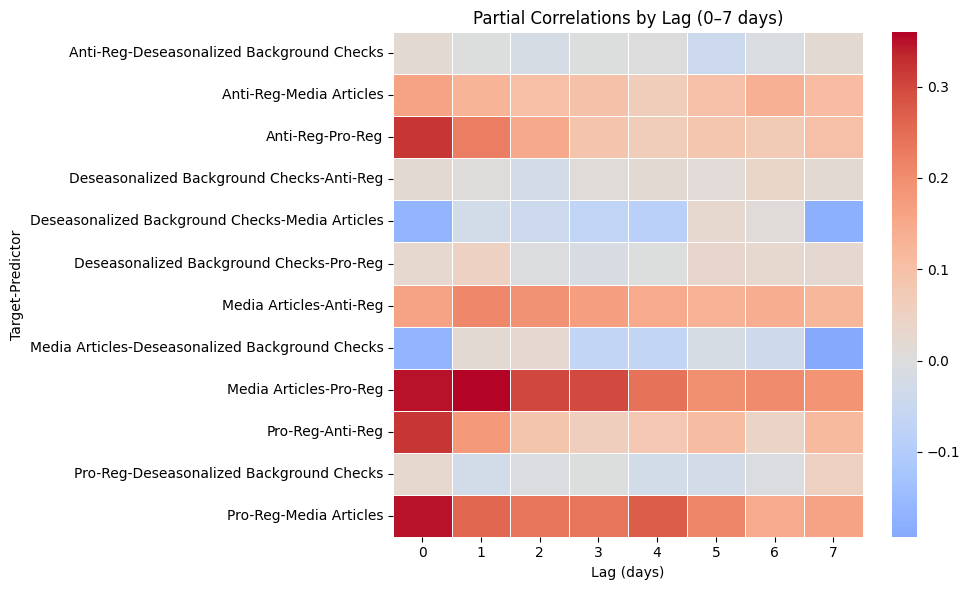

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns
pivot = partial_corr_df.pivot_table(
    index=["Target", "Predictor"],
    columns="Lag (days)",
    values="Partial Correlation"
)


plt.figure(figsize=(10, 6))
sns.heatmap(
    pivot,
    center=0,
    cmap="coolwarm",
    linewidths=0.5
)
plt.title("Partial Correlations by Lag (0–7 days)")
plt.tight_layout()
plt.show()

In [52]:
import numpy as np
import pandas as pd
from statsmodels.tsa.api import VAR

# -----------------------------
# Configuration
# -----------------------------
VARS = [
    "Deseasonalized Background Checks",
    "Media Articles",
    "Anti-Reg",
    "Pro-Reg",
]

# Cholesky ordering matters. This ordering means:
# Media, Anti-Reg, Pro-Reg can affect Checks contemporaneously,
# and Checks is "last" contemporaneously.
# Feel free to change the order, but KEEP it explicit.
ORDER = [
    "Media Articles",
    "Anti-Reg",
    "Pro-Reg",
    "Deseasonalized Background Checks",
]

MAX_LAG = 7          # you want to inspect the effect at lag 7
IRF_HORIZON = 14     # how many steps ahead to compute responses (>= 7)
ALPHA = 0.05         # 95% intervals

impulse_var = "Pro-Reg"
response_var = "Deseasonalized Background Checks"
lag_of_interest = 7

# -----------------------------
# Prepare data
# -----------------------------
df = merged[ORDER].dropna().copy()

# (Optional but recommended) make sure series are numeric
df = df.apply(pd.to_numeric, errors="coerce").dropna()

# -----------------------------
# Fit VAR with fixed lag order = 7
# -----------------------------
model = VAR(df)
res = model.fit(MAX_LAG)

print(res.summary())

# -----------------------------
# Impulse Response (Cholesky-orthogonalized)
# -----------------------------
# statsmodels VARResults.irf() uses orthogonalized shocks by default (Cholesky of residual covariance)
irf = res.irf(IRF_HORIZON)

# Extract the IRF array:
# shape: (horizon+1, k_endog, k_endog)
# indexing: [step, response_index, impulse_index]
k_names = list(df.columns)
imp_i = k_names.index(impulse_var)
resp_i = k_names.index(response_var)

irf_vals = irf.irfs[:, resp_i, imp_i]  # includes step 0

# Confidence intervals (asymptotic)
# Returns (lower, upper) arrays of shape (horizon+1, k, k)
lower, upper = irf.cov(orth=True).irf_errband_mc(
    orth=True, repl=2000, signif=ALPHA
)[0:2]  # Monte Carlo error bands (more robust than purely asymptotic)

# Note: irf_errband_mc returns (lower, upper) in older/newer versions differently.
# If this line errors, use the fallback block below.

try:
    lower_vals = lower[:, resp_i, imp_i]
    upper_vals = upper[:, resp_i, imp_i]
except Exception:
    # Fallback: asymptotic bands
    lower2, upper2 = irf.errband_mc(orth=True, repl=2000, signif=ALPHA)
    lower_vals = lower2[:, resp_i, imp_i]
    upper_vals = upper2[:, resp_i, imp_i]

# -----------------------------
# Print the IRF value at "lag 7"
# -----------------------------
# In IRF terminology, this is the response at step 7 following a 1-s.d. orthogonal shock at step 0.
if lag_of_interest > IRF_HORIZON:
    raise ValueError("IRF_HORIZON must be >= lag_of_interest")

print("\n--- Impulse Response (Cholesky-orthogonalized) ---")
print(f"Ordering (Cholesky): {k_names}")
print(f"Impulse:  {impulse_var} (1 s.d. orthogonal shock)")
print(f"Response: {response_var}")
print(f"Step {lag_of_interest} response = {irf_vals[lag_of_interest]:.6f}")
print(f"95% MC band: [{lower_vals[lag_of_interest]:.6f}, {upper_vals[lag_of_interest]:.6f}]")

# -----------------------------
# Optional: put the whole IRF path into a tidy DataFrame
# -----------------------------
irf_df = pd.DataFrame({
    "step": np.arange(IRF_HORIZON + 1),
    "irf": irf_vals,
    "lower": lower_vals,
    "upper": upper_vals,
})
print("\nIRF path (first few rows):")
print(irf_df.head(10))

# -----------------------------
# Optional: quick plot (matplotlib)
# -----------------------------
import matplotlib.pyplot as plt

plt.figure()
plt.plot(irf_df["step"], irf_df["irf"])
plt.fill_between(irf_df["step"], irf_df["lower"], irf_df["upper"], alpha=0.2)
plt.axhline(0, linewidth=1)
plt.title(f"IRF: {response_var} response to {impulse_var} shock")
plt.xlabel("Step")
plt.ylabel("Response (in units of response variable)")
plt.show()


  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Mon, 05, Jan, 2026
Time:                     16:06:00
--------------------------------------------------------------------
No. of Equations:         4.00000    BIC:                    28.0511
Nobs:                     1581.00    HQIC:                   27.8037
Log likelihood:          -30720.5    FPE:                1.02674e+12
AIC:                      27.6574    Det(Omega_mle):     9.54738e+11
--------------------------------------------------------------------
Results for equation Media Articles
                                         coefficient       std. error           t-stat            prob
------------------------------------------------------------------------------------------------------
const                                       2.668785         0.695159            3.839           0.000
L1.Media Articles                           0.305287         0.025

AttributeError: 'numpy.ndarray' object has no attribute 'irf_errband_mc'

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Mon, 05, Jan, 2026
Time:                     16:06:55
--------------------------------------------------------------------
No. of Equations:         4.00000    BIC:                    28.0511
Nobs:                     1581.00    HQIC:                   27.8037
Log likelihood:          -30720.5    FPE:                1.02674e+12
AIC:                      27.6574    Det(Omega_mle):     9.54738e+11
--------------------------------------------------------------------
Results for equation Media Articles
                                         coefficient       std. error           t-stat            prob
------------------------------------------------------------------------------------------------------
const                                       2.668785         0.695159            3.839           0.000
L1.Media Articles                           0.305287         0.025

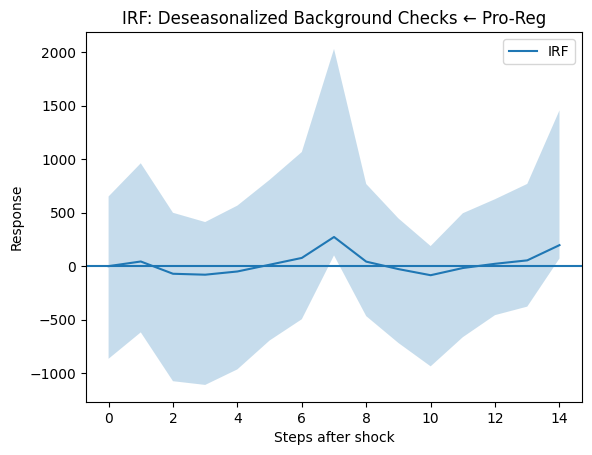

In [53]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.api import VAR

# -----------------------------
# Configuration
# -----------------------------
ORDER = [
    "Media Articles",
    "Anti-Reg",
    "Pro-Reg",
    "Deseasonalized Background Checks",
]

impulse_var = "Pro-Reg"
response_var = "Deseasonalized Background Checks"

VAR_LAG = 7
IRF_HORIZON = 14
N_MC = 2000
ALPHA = 0.05

# -----------------------------
# Prepare data
# -----------------------------
df = merged[ORDER].dropna().copy()
df = df.apply(pd.to_numeric, errors="coerce").dropna()

# -----------------------------
# Fit VAR
# -----------------------------
model = VAR(df)
res = model.fit(VAR_LAG)

print(res.summary())

# -----------------------------
# Compute IRFs (Cholesky-orthogonalized)
# -----------------------------
irf = res.irf(IRF_HORIZON)

names = list(df.columns)
imp_i = names.index(impulse_var)
resp_i = names.index(response_var)

# IRF values
irf_vals = irf.irfs[:, resp_i, imp_i]

# -----------------------------
# Monte Carlo confidence bands (VERSION-SAFE)
# -----------------------------
lower, upper = irf.errband_mc(
    orth=True,
    repl=N_MC,
    signif=ALPHA
)

lower_vals = lower[:, resp_i, imp_i]
upper_vals = upper[:, resp_i, imp_i]

# -----------------------------
# Print step-7 response
# -----------------------------
step = 7
print("\n--- Impulse Response Result ---")
print(f"Impulse:  {impulse_var}")
print(f"Response: {response_var}")
print(f"Step {step} IRF = {irf_vals[step]:.6f}")
print(f"95% CI = [{lower_vals[step]:.6f}, {upper_vals[step]:.6f}]")

# -----------------------------
# Plot
# -----------------------------
steps = np.arange(IRF_HORIZON + 1)

plt.figure()
plt.plot(steps, irf_vals, label="IRF")
plt.fill_between(steps, lower_vals, upper_vals, alpha=0.25)
plt.axhline(0)
plt.xlabel("Steps after shock")
plt.ylabel("Response")
plt.title(f"IRF: {response_var} ← {impulse_var}")
plt.legend()
plt.show()

In [56]:
import pandas as pd
import statsmodels.api as sm

# -----------------------------
# Configuration
# -----------------------------
LAG = 7

y = "Deseasonalized Background Checks"
x = "Pro-Reg"
controls = [
    "Media Articles",
    "Anti-Reg",
    "Deseasonalized Background Checks"
]

# -----------------------------
# Build LP dataset
# -----------------------------
df = merged.copy()

df["X_lag7"] = df[x].shift(LAG)
df["Y_t"] = df[y]

# Include lags of controls (same as VAR order)
for l in range(1, 8):
    df[f"Y_l{l}"] = df[y].shift(l)
    df[f"Media_l{l}"] = df["Media Articles"].shift(l)
    df[f"Anti_l{l}"] = df["Anti-Reg"].shift(l)

regressors = (
    ["X_lag7"] +
    [f"Y_l{l}" for l in range(1, 8)] +
    [f"Media_l{l}" for l in range(1, 8)] +
    [f"Anti_l{l}" for l in range(1, 8)]
)

df_lp = df[["Y_t"] + regressors].dropna()

X = sm.add_constant(df_lp[regressors])
Y = df_lp["Y_t"]

# -----------------------------
# Estimate LP with HAC SEs
# -----------------------------
model = sm.OLS(Y, X).fit(
    cov_type="HAC",
    cov_kwds={"maxlags": LAG}
)

model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    Y_t   R-squared:                       0.668
Model:                            OLS   Adj. R-squared:                  0.663
Method:                 Least Squares   F-statistic:                     93.90
Date:                Mon, 05 Jan 2026   Prob (F-statistic):          2.38e-266
Time:                        16:37:11   Log-Likelihood:                -17501.
No. Observations:                1581   AIC:                         3.505e+04
Df Residuals:                    1558   BIC:                         3.517e+04
Df Model:                          22                                         
Covariance Type:                  HAC                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       7984.0440   3118.772      2.560      0.010    1871.363    1.41e+04
X_lag7       214.9745     76.035      2.827      0.005      65.949     364.000
Y_l1           0.1449      0.036      4.058      0.000       0.075       0.215
Y_l2          -0.0229      0.025     -0.914      0.361      -0.072       0.026
Y_l3           0.0185      0.020      0.936      0.349      -0.020       0.057
Y_l4           0.0618      0.021      2.936      0.003       0.021       0.103
Y_l5          -0.0397      0.018     -2.182      0.029      -0.075      -0.004
Y_l6           0.0833      0.025      3.395      0.001       0.035       0.131
Y_l7           0.6834      0.035     19.550      0.000       0.615       0.752
Media_l1     250.0874     87.044      2.873      0.004      79.484     420.691
Media_l2    -139.0301     85.613     -1.624      0.104    -306.829      28.768
Media_l3      18.9818     97.156      0.195      0.845    -171.440     209.403
Media_l4    -180.2125    131.569     -1.370      0.171    -438.083      77.658
Media_l5     205.2576     92.756      2.213      0.027      23.460     387.055
Media_l6     157.4393    103.804      1.517      0.129     -46.012     360.891
Media_l7    -503.2312     99.297     -5.068      0.000    -697.849    -308.613
Anti_l1      -95.7200     72.731     -1.316      0.188    -238.269      46.829
Anti_l2      -92.7935     77.246     -1.201      0.230    -244.193      58.606
Anti_l3       69.3404     89.135      0.778      0.437    -105.362     244.042
Anti_l4      114.6247    100.546      1.140      0.254     -82.443     311.692
Anti_l5      -98.6870     96.694     -1.021      0.307    -288.203      90.829
Anti_l6      107.4303     73.814      1.455      0.146     -37.242     252.103
Anti_l7       48.1326     99.225      0.485      0.628    -146.344     242.609
==============================================================================
Omnibus:                      343.196   Durbin-Watson:                   1.973
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             4887.704
Skew:                           0.597   Prob(JB):                         0.00
Kurtosis:                      11.531   Cond. No.                     1.64e+06
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity and autocorrelation robust (HAC) using 7 lags and without small sample correction
[2] The condition number is large, 1.64e+06. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [55]:
model.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    Y_t   R-squared:                       0.668
Model:                            OLS   Adj. R-squared:                  0.663
Method:                 Least Squares   F-statistic:                     93.90
Date:                Mon, 05 Jan 2026   Prob (F-statistic):          2.38e-266
Time:                        16:14:47   Log-Likelihood:                -17501.
No. Observations:                1581   AIC:                         3.505e+04
Df Residuals:                    1558   BIC:                         3.517e+04
Df Model:                          22                                         
Covariance Type:                  HAC                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       7984.0440   3118.772      2.560      0.010    1871.363    1.41e+04
X_lag7       214.9745     76.035      2.827      0.005      65.949     364.000
Y_l1           0.1449      0.036      4.058      0.000       0.075       0.215
Y_l2          -0.0229      0.025     -0.914      0.361      -0.072       0.026
Y_l3           0.0185      0.020      0.936      0.349      -0.020       0.057
Y_l4           0.0618      0.021      2.936      0.003       0.021       0.103
Y_l5          -0.0397      0.018     -2.182      0.029      -0.075      -0.004
Y_l6           0.0833      0.025      3.395      0.001       0.035       0.131
Y_l7           0.6834      0.035     19.550      0.000       0.615       0.752
Media_l1     250.0874     87.044      2.873      0.004      79.484     420.691
Media_l2    -139.0301     85.613     -1.624      0.104    -306.829      28.768
Media_l3      18.9818     97.156      0.195      0.845    -171.440     209.403
Media_l4    -180.2125    131.569     -1.370      0.171    -438.083      77.658
Media_l5     205.2576     92.756      2.213      0.027      23.460     387.055
Media_l6     157.4393    103.804      1.517      0.129     -46.012     360.891
Media_l7    -503.2312     99.297     -5.068      0.000    -697.849    -308.613
Anti_l1      -95.7200     72.731     -1.316      0.188    -238.269      46.829
Anti_l2      -92.7935     77.246     -1.201      0.230    -244.193      58.606
Anti_l3       69.3404     89.135      0.778      0.437    -105.362     244.042
Anti_l4      114.6247    100.546      1.140      0.254     -82.443     311.692
Anti_l5      -98.6870     96.694     -1.021      0.307    -288.203      90.829
Anti_l6      107.4303     73.814      1.455      0.146     -37.242     252.103
Anti_l7       48.1326     99.225      0.485      0.628    -146.344     242.609
==============================================================================
Omnibus:                      343.196   Durbin-Watson:                   1.973
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             4887.704
Skew:                           0.597   Prob(JB):                         0.00
Kurtosis:                      11.531   Cond. No.                     1.64e+06
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity and autocorrelation robust (HAC) using 7 lags and without small sample correction
[2] The condition number is large, 1.64e+06. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

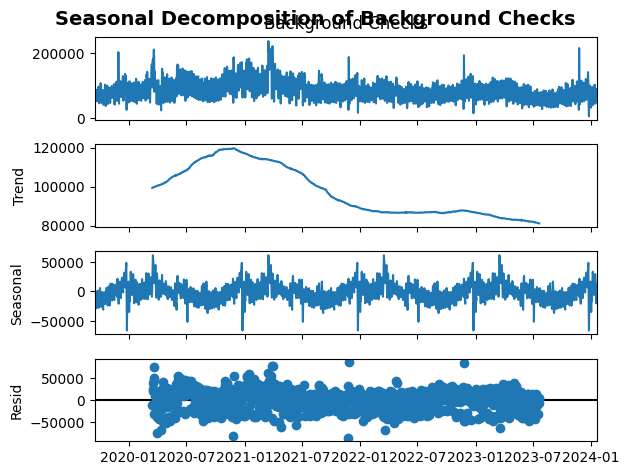

In [39]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

# Ensure timestamp is the index
merged = merged.set_index("timestamp").asfreq("D")  # daily frequency

# Classical seasonal decomposition (additive model is typical for counts)
result = seasonal_decompose(merged["Background Checks"], model="additive", period=365)

# Deseasonalized series = observed - seasonal
merged["Background Checks_deseasonalized"] = result.observed - result.seasonal

# Plot decomposition
result.plot()
plt.suptitle("Seasonal Decomposition of Background Checks", fontsize=14, fontweight='bold')
plt.show()

In [40]:
merged.head()

,Background Checks,Anti-Reg,Pro-Reg,Media Articles,Deseasonalized Background Checks,Background Checks_deseasonalized
timestamp,,,,,,
2019-09-15,46741,1,0,18.0,58848.885371,58848.885371
2019-09-16,69574,0,0,5.0,78874.446102,78874.446102
2019-09-17,85434,0,0,5.0,87451.331033,87451.331033
2019-09-18,83936,0,0,6.0,85801.708202,85801.708202
2019-09-19,75939,0,0,9.0,89730.671673,89730.671673


In [41]:
from causationentropy.core import discover_network
from sklearn.preprocessing import StandardScaler
import numpy as np

data = merged[["Deseasonalized Background Checks", 'Anti-Reg', 'Pro-Reg', 'Media Articles']]

scaler = StandardScaler()
data = pd.DataFrame(
    scaler.fit_transform(data),
    columns=data.columns,
    index=data.index
)

network = discover_network(
    data,
    information='gaussian',
    max_lag=7,              # Maximum time lag to consider
    alpha_forward=0.005,     # Forward selection significance
    alpha_backward=0.005,    # Backward elimination significance
    n_shuffles=200          # Permutation test iterations
)

Estimating edges for node 0 (Deseasonalized Background Checks)


/home/kslote/Desktop/causalentropy/case_studies/venv/lib/python3.10/site-packages/causationentropy/core/information/conditional_mutual_information.py:80: RuntimeWarning: invalid value encountered in scalar subtract
  cmi = 0.5 * (SXZ + SYZ - SZ - SXYZ)


Estimating edges for node 1 (Anti-Reg)
Estimating edges for node 2 (Pro-Reg)
Estimating edges for node 3 (Media Articles)


In [42]:
data.corr()

,Deseasonalized Background Checks,Anti-Reg,Pro-Reg,Media Articles
Deseasonalized Background Checks,1.000000,-0.022541,-0.039989,-0.166451
Anti-Reg,-0.022541,1.000000,0.405579,0.304690
Pro-Reg,-0.039989,0.405579,1.000000,0.427082
Media Articles,-0.166451,0.304690,0.427082,1.000000


/tmp/ipykernel_411520/3156852958.py:64: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap(CONFIG['colormaps'][i % len(CONFIG['colormaps'])])(cmis / max_cmi)
/tmp/ipykernel_411520/3156852958.py:62: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap(CONFIG['colormaps'][i % len(CONFIG['colormaps'])])(normalized_cmis)
/tmp/ipykernel_411520/3156852958.py:83: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = plt.cm.get_c

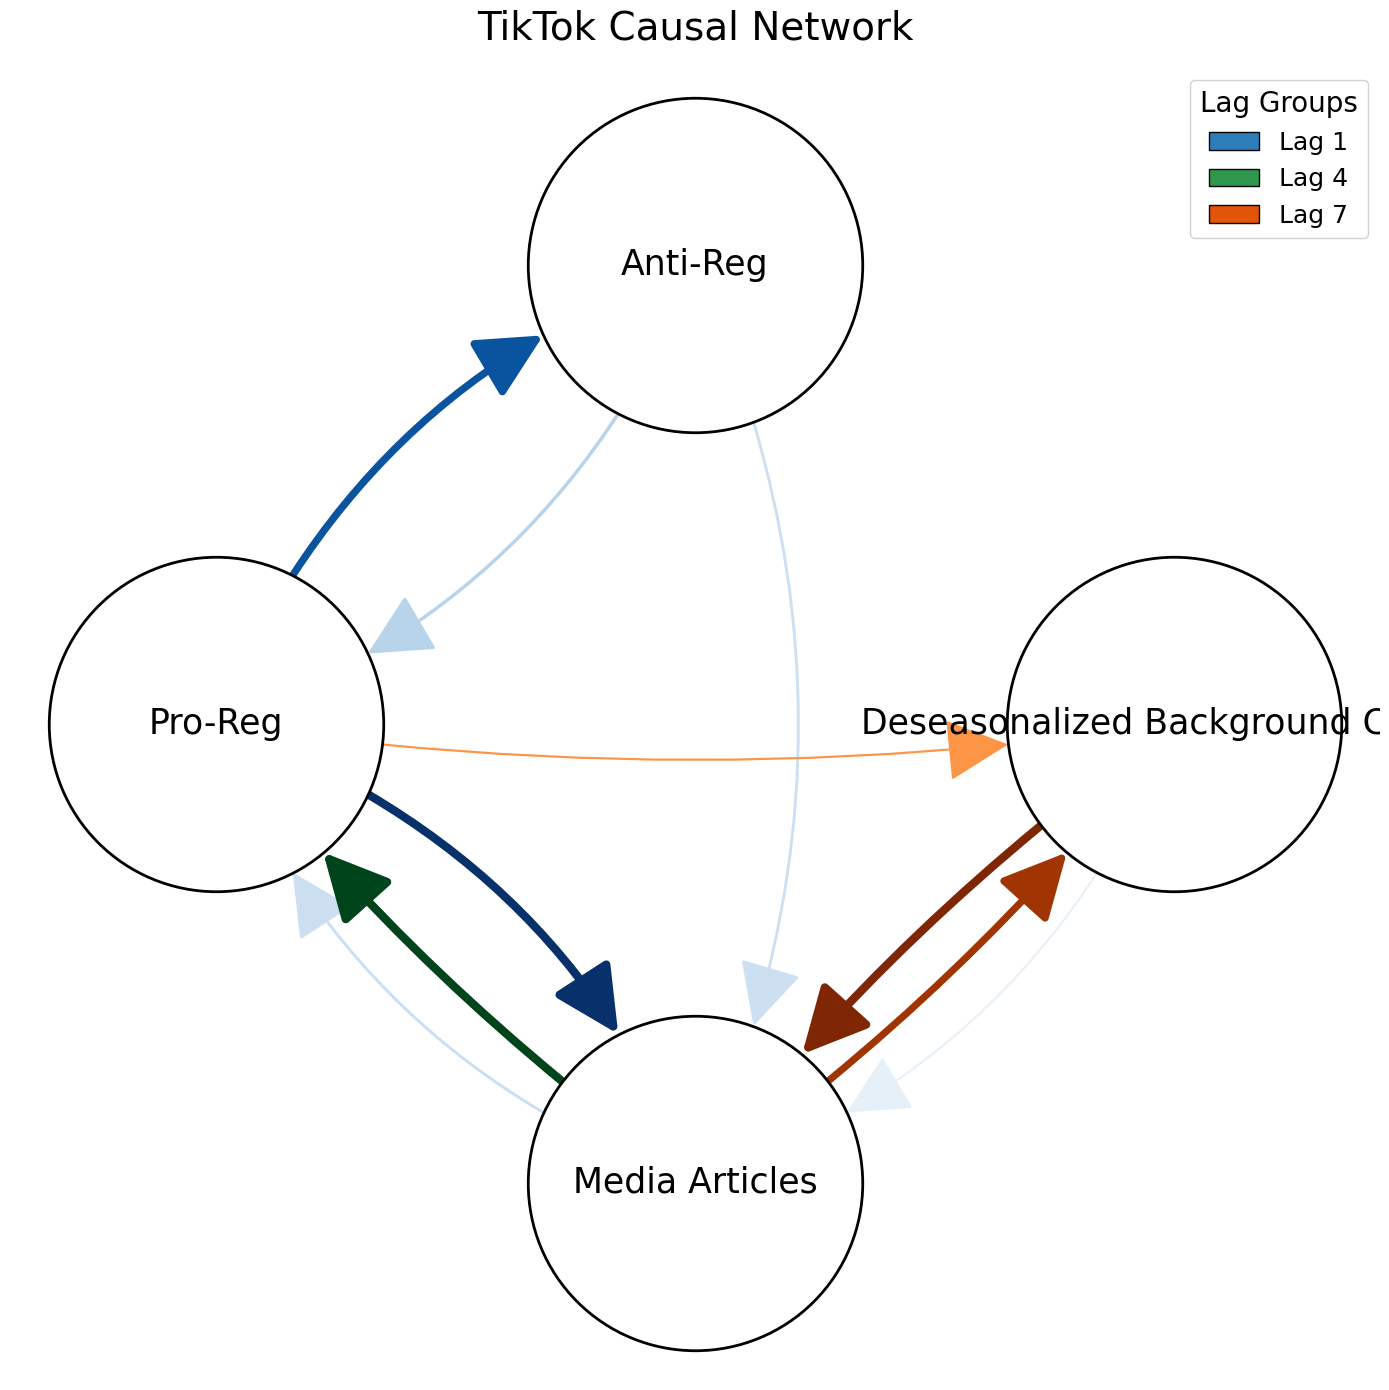

In [43]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import Normalize
from collections import defaultdict
from matplotlib.patches import Patch

# Configuration
CONFIG = {
    'node_size': 58000,
    'arrowsize': 100,
    'label_fontsize': 25,
    'figsize': (14, 14),  # Increased figure size
    'edge_width_range': (1.0, 6.0),
    'node_linewidth': 2.0,
    'layout': 'circular',
    'colormaps': ['Blues', 'Greens', 'Oranges', 'Purples', 'Reds', 'Greys', 'YlOrBr']
}

# Get layout positions
pos = nx.circular_layout(network)

# Extract edge data
edge_data = defaultdict(list)
for u, v, k, data in network.edges(keys=True, data=True):
    lag = data.get('lag', 0)
    cmi = max(0.0, float(data.get('cmi', 0.0)))
    edge_data[lag].append((u, v, cmi))

# Create plot
fig, ax = plt.subplots(figsize=CONFIG['figsize'])

# Draw nodes
nx.draw_networkx_nodes(
    network, pos,
    node_size=CONFIG['node_size'],
    node_color='white',
    edgecolors='black',
    linewidths=CONFIG['node_linewidth'],
    ax=ax
)

# Draw labels
nx.draw_networkx_labels(network, pos, font_size=CONFIG['label_fontsize'], ax=ax)

# Draw edges by lag
for i, (lag, edges) in enumerate(sorted(edge_data.items())):
    if not edges:
        continue
    
    # Extract CMI values and normalize
    cmis = np.array([e[2] for e in edges])
    max_cmi = cmis.max() if cmis.max() > 0 else 1.0
    
    # Calculate edge properties
    widths = CONFIG['edge_width_range'][0] + \
             (CONFIG['edge_width_range'][1] - CONFIG['edge_width_range'][0]) * (cmis / max_cmi)
    
    # Make colors darker for lag 7
    if lag == 7:
        normalized_cmis = 0.4 + 0.6 * (cmis / max_cmi)
        colors = plt.cm.get_cmap(CONFIG['colormaps'][i % len(CONFIG['colormaps'])])(normalized_cmis)
    else:
        colors = plt.cm.get_cmap(CONFIG['colormaps'][i % len(CONFIG['colormaps'])])(cmis / max_cmi)
    
    # Draw edges for this lag
    nx.draw_networkx_edges(
        network, pos,
        edgelist=[(e[0], e[1]) for e in edges],
        edge_color=colors,
        width=widths,
        arrows=True,
        arrowstyle='-|>',
        arrowsize=CONFIG['arrowsize'],
        connectionstyle=f'arc3,rad={0.15 * (i - len(edge_data)/2)}',
        node_size=CONFIG['node_size'],
        ax=ax
    )

# Create legend (removed duplicate legend code)
legend_elements = []
for i, lag in enumerate(sorted(edge_data.keys())):
    colormap = plt.cm.get_cmap(CONFIG['colormaps'][i % len(CONFIG['colormaps'])])
    color = colormap(0.7)
    legend_elements.append(Patch(facecolor=color, edgecolor='black', label=f'Lag {lag}'))

# Add legend with better positioning
ax.legend(handles=legend_elements, loc='upper right', fontsize=18, 
          title='Lag Groups', title_fontsize=20, framealpha=0.9)

# Set axis properties
ax.set_axis_off()
ax.set_title('TikTok Causal Network', fontsize=28, pad=20)

# Adjust margins to ensure everything fits
plt.margins(0.15)  # Add 15% margin around the plot
plt.tight_layout()
plt.show()

In [44]:
target_u = "Pro-Reg"
target_v = "Deseasonalized Background Checks"

edges = []
for u, v, k, d in network.edges(keys=True, data=True):
    if u == target_u and v == target_v:
        edges.append((d.get("lag"), d.get("cmi"), k))

edges = sorted(edges, key=lambda x: (x[0] if x[0] is not None else -1))
print(f"Edges {target_u} -> {target_v}:")
for lag, cmi, k in edges:
    print(f"  lag={lag}, cmi={cmi}, key={k}")


Edges Pro-Reg -> Deseasonalized Background Checks:
  lag=7, cmi=0.0026854894854180383, key=0


In [45]:
import pandas as pd
import numpy as np

target_u = "Pro-Reg"
target_v = "Deseasonalized Background Checks"

results = []

for u, v, k, d in network.edges(keys=True, data=True):
    if u == target_u and v == target_v:
        lag = int(d.get("lag", 0))
        cmi = float(d.get("cmi", np.nan))

        # Align series for lagged correlation
        x = merged[u].shift(lag)
        y = merged[v]

        aligned = pd.concat([x, y], axis=1).dropna()
        corr = aligned.iloc[:, 0].corr(aligned.iloc[:, 1])

        results.append({
            "u": u,
            "v": v,
            "lag": lag,
            "cmi": cmi,
            "lagged_corr": corr
        })

# Sort and display
results = sorted(results, key=lambda r: r["lag"])

print(f"{target_u} → {target_v}")
for r in results:
    print(
        f"lag={r['lag']}: "
        f"corr={r['lagged_corr']:.3f}, "
        f"cmi={r['cmi']:.4f}"
    )


Pro-Reg → Deseasonalized Background Checks
lag=7: corr=-0.012, cmi=0.0027
